In [ ]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

root = Path.cwd()

# Constants and parameters
m_c12_6 = 11.9967074084982  # amu
amu = 931.49410372          # MeV/c^2
mass = m_c12_6 * amu        # MeV/c^2

# Load OPAL
opal_lebt = np.loadtxt(root / "opal" / "lebt.stat", skiprows=303)

s_opal = opal_lebt[:, 1]       # m
N_opal = opal_lebt[:, 2]
E_opal = opal_lebt[:, 4]       # MeV

sigma_x = opal_lebt[:, 5]      # m
sigma_y = opal_lebt[:, 6]      # m
sigma_px = opal_lebt[:, 8]     # normalized momentum
sigma_py = opal_lebt[:, 9]     # normalized momentum

emit_x_norm = opal_lebt[:, 11] # m rad
emit_y_norm = opal_lebt[:, 12] # m rad

rho_xpx = opal_lebt[:, 26]
rho_ypy = opal_lebt[:, 27]


rms_x_opal = sigma_x * 1e3
rms_y_opal = sigma_y * 1e3

emmit_x_opal = emit_x_norm * 1e6
emmit_y_opal = emit_y_norm * 1e6

gamma_opal = 1 + E_opal / mass
betagamma_opal = np.sqrt(gamma_opal**2 - 1)

emit_x_geom = emit_x_norm / betagamma_opal
emit_y_geom = emit_y_norm / betagamma_opal

emit_x_geom_opal = emit_x_geom * 1e6
emit_y_geom_opal = emit_y_geom * 1e6

beta_x_opal = sigma_x**2 / emit_x_geom
beta_y_opal = sigma_y**2 / emit_y_geom

cov_xpx = rho_xpx * sigma_x * sigma_px
cov_ypy = rho_ypy * sigma_y * sigma_py

alpha_x_opal = -cov_xpx / emit_x_norm
alpha_y_opal = -cov_ypy / emit_y_norm

P_opal = np.sqrt(E_opal * (E_opal + 2 * mass))  # MeV/c

sigma_px_opal_mom = sigma_px * mass
sigma_py_opal_mom = sigma_py * mass

# OPAL normalized momentum to RMS divergence [mrad]
sigma_px_opal = 1e3 * sigma_px / betagamma_opal
sigma_py_opal = 1e3 * sigma_py / betagamma_opal

# Load RF-Track

rftrack_lebt = np.loadtxt(root / "rftrack" / "rftrack_lebt_transport.txt", skiprows=1)

s_rf = rftrack_lebt[:, 0]
rms_x_rf = rftrack_lebt[:, 1]
rms_y_rf = rftrack_lebt[:, 2]
N_rf = rftrack_lebt[:, 3]

P_rf = rftrack_lebt[:, 4]

beta_x_rf = rftrack_lebt[:, 5]
beta_y_rf = rftrack_lebt[:, 6]
beta_z_rf = rftrack_lebt[:, 7]

alpha_x_rf = rftrack_lebt[:, 8]
alpha_y_rf = rftrack_lebt[:, 9]
alpha_z_rf = rftrack_lebt[:, 10]

E_rf = rftrack_lebt[:, 11]

sigma_px_rf = rftrack_lebt[:, 12]  # mrad
sigma_py_rf = rftrack_lebt[:, 13]  # mrad

sigma_px_rf_mom = P_rf * sigma_px_rf / 1000
sigma_py_rf_mom = P_rf * sigma_py_rf / 1000

# Load TraceWin

tracewin_lebt_x = np.loadtxt(root / "inputs" / "Chart_rmssizeX(mm).txt", skiprows=1)
tracewin_lebt_y = np.loadtxt(root / "inputs" / "Chart_rmssizeY(mm).txt", skiprows=1)
tracewin_trans = np.loadtxt(root / "inputs" / "Chart_Transmission(%).txt", skiprows=1)
tracewin_envelope = np.loadtxt(root / "inputs" / "envelopes.txt", skiprows=2)

s_tracewin_x = tracewin_lebt_x[:, 0]
s_tracewin_y = tracewin_lebt_y[:, 0]
s_tracewin_N = tracewin_trans[:, 0]
s_tracewin_envelope = tracewin_envelope[:, 0]

rms_x_tracewin = tracewin_lebt_x[:, 1]
rms_y_tracewin = tracewin_lebt_y[:, 1]
N_tracewin = tracewin_trans[:, 1]

E_tracewin = tracewin_envelope[:, 9] / 100   # MeV
beta_x_tracewin = tracewin_envelope[:, 24]
beta_y_tracewin = tracewin_envelope[:, 25]

sigma_xp_tracewin = tracewin_envelope[:, 13]  # rad
sigma_yp_tracewin = tracewin_envelope[:, 15]  # rad

gamma_tracewin = 1 + tracewin_envelope[:, 1]
betagamma_tracewin = np.sqrt(gamma_tracewin**2 - 1)

P_tracewin = mass * betagamma_tracewin  # MeV/c

sigma_px_tracewin = P_tracewin * sigma_xp_tracewin
sigma_py_tracewin = P_tracewin * sigma_yp_tracewin



# Helpers

def sort_by_s(s, y):
    idx = np.argsort(s)
    return s[idx], y[idx]

def relative_error_percent(code, ref, eps=1e-12):
    return 100 * (code - ref) / (ref + eps)

def print_stats(name, err):
    print(f"\n{name}")
    print(f"  mean relative error       = {np.mean(err): .4f} %")
    print(f"  RMS relative error        = {np.sqrt(np.mean(err**2)): .4f} %")

# Sort 

idx_opal = np.argsort(s_opal)

s_opal = s_opal[idx_opal]
N_opal = N_opal[idx_opal]
E_opal = E_opal[idx_opal]
P_opal = P_opal[idx_opal]

rms_x_opal = rms_x_opal[idx_opal]
rms_y_opal = rms_y_opal[idx_opal]

beta_x_opal = beta_x_opal[idx_opal]
beta_y_opal = beta_y_opal[idx_opal]

alpha_x_opal = alpha_x_opal[idx_opal]
alpha_y_opal = alpha_y_opal[idx_opal]

sigma_px_opal = sigma_px_opal[idx_opal]
sigma_py_opal = sigma_py_opal[idx_opal]

sigma_px_opal_mom = sigma_px_opal_mom[idx_opal]
sigma_py_opal_mom = sigma_py_opal_mom[idx_opal]

idx_rf = np.argsort(s_rf)

s_rf = s_rf[idx_rf]
N_rf = N_rf[idx_rf]
E_rf = E_rf[idx_rf]
P_rf = P_rf[idx_rf]

rms_x_rf = rms_x_rf[idx_rf]
rms_y_rf = rms_y_rf[idx_rf]

beta_x_rf = beta_x_rf[idx_rf]
beta_y_rf = beta_y_rf[idx_rf]
beta_z_rf = beta_z_rf[idx_rf]

alpha_x_rf = alpha_x_rf[idx_rf]
alpha_y_rf = alpha_y_rf[idx_rf]
alpha_z_rf = alpha_z_rf[idx_rf]

sigma_px_rf = sigma_px_rf[idx_rf]
sigma_py_rf = sigma_py_rf[idx_rf]

sigma_px_rf_mom = sigma_px_rf_mom[idx_rf]
sigma_py_rf_mom = sigma_py_rf_mom[idx_rf]

idx_tw_x = np.argsort(s_tracewin_x)
s_tracewin_x = s_tracewin_x[idx_tw_x]
rms_x_tracewin = rms_x_tracewin[idx_tw_x]

idx_tw_y = np.argsort(s_tracewin_y)
s_tracewin_y = s_tracewin_y[idx_tw_y]
rms_y_tracewin = rms_y_tracewin[idx_tw_y]

idx_tw_N = np.argsort(s_tracewin_N)
s_tracewin_N = s_tracewin_N[idx_tw_N]
N_tracewin = N_tracewin[idx_tw_N]

idx_tw_env = np.argsort(s_tracewin_envelope)
s_tracewin_envelope = s_tracewin_envelope[idx_tw_env]
E_tracewin = E_tracewin[idx_tw_env]
beta_x_tracewin = beta_x_tracewin[idx_tw_env]
beta_y_tracewin = beta_y_tracewin[idx_tw_env]

s_min = max(
    s_opal.min(),
    s_rf.min(),
    s_tracewin_x.min(),
    s_tracewin_y.min(),
    s_tracewin_N.min(),
    s_tracewin_envelope.min()
)

s_max = min(
    s_opal.max(),
    s_rf.max(),
    s_tracewin_x.max(),
    s_tracewin_y.max(),
    s_tracewin_N.max(),
    s_tracewin_envelope.max()
)

mask = (s_tracewin_x >= s_min) & (s_tracewin_x <= s_max)

s_common = s_tracewin_x[mask]


rms_x_tw_c = rms_x_tracewin[mask]
rms_y_tw_c = np.interp(s_common, s_tracewin_y, rms_y_tracewin)

rms_x_opal_c = np.interp(s_common, s_opal, rms_x_opal)
rms_y_opal_c = np.interp(s_common, s_opal, rms_y_opal)

rms_x_rf_c = np.interp(s_common, s_rf, rms_x_rf)
rms_y_rf_c = np.interp(s_common, s_rf, rms_y_rf)

N_tw_c = np.interp(s_common, s_tracewin_N, N_tracewin)
N_opal_c = np.interp(s_common, s_opal, N_opal)
N_rf_c = np.interp(s_common, s_rf, N_rf)

T_tw_c = N_tw_c / N_tw_c[0]
T_opal_c = N_opal_c / N_opal_c[0]
T_rf_c = N_rf_c / N_rf_c[0]

E_tracewin_c = np.interp(s_common, s_tracewin_envelope, E_tracewin)
E_opal_c = np.interp(s_common, s_opal, E_opal)
E_rf_c = np.interp(s_common, s_rf, E_rf)

P_opal_c = np.interp(s_common, s_opal, P_opal)
P_rf_c = np.interp(s_common, s_rf, P_rf)

sigma_px_opal_c = np.interp(s_common, s_opal, sigma_px_opal)
sigma_py_opal_c = np.interp(s_common, s_opal, sigma_py_opal)
sigma_px_rf_c = np.interp(s_common, s_rf, sigma_px_rf)
sigma_py_rf_c = np.interp(s_common, s_rf, sigma_py_rf)
sigma_px_tracewin_c = np.interp(s_common, s_tracewin_envelope, sigma_px_tracewin)
sigma_py_tracewin_c = np.interp(s_common, s_tracewin_envelope, sigma_py_tracewin)

sigma_px_opal_mom_c = np.interp(s_common, s_opal, sigma_px_opal_mom)
sigma_py_opal_mom_c = np.interp(s_common, s_opal, sigma_py_opal_mom)

sigma_px_rf_mom_c = np.interp(s_common, s_rf, sigma_px_rf_mom)
sigma_py_rf_mom_c = np.interp(s_common, s_rf, sigma_py_rf_mom)

beta_x_tw_c = np.interp(s_common, s_tracewin_envelope, beta_x_tracewin)
beta_y_tw_c = np.interp(s_common, s_tracewin_envelope, beta_y_tracewin)

beta_x_opal_c = np.interp(s_common, s_opal, beta_x_opal)
beta_y_opal_c = np.interp(s_common, s_opal, beta_y_opal)

beta_x_rf_c = np.interp(s_common, s_rf, beta_x_rf)
beta_y_rf_c = np.interp(s_common, s_rf, beta_y_rf)
beta_z_rf_c = np.interp(s_common, s_rf, beta_z_rf)

alpha_x_opal_c = np.interp(s_common, s_opal, alpha_x_opal)
alpha_y_opal_c = np.interp(s_common, s_opal, alpha_y_opal)

alpha_x_rf_c = np.interp(s_common, s_rf, alpha_x_rf)
alpha_y_rf_c = np.interp(s_common, s_rf, alpha_y_rf)
alpha_z_rf_c = np.interp(s_common, s_rf, alpha_z_rf)

err_x_opal = relative_error_percent(rms_x_opal_c, rms_x_tw_c)
err_x_rf = relative_error_percent(rms_x_rf_c, rms_x_tw_c)

err_y_opal = relative_error_percent(rms_y_opal_c, rms_y_tw_c)
err_y_rf = relative_error_percent(rms_y_rf_c, rms_y_tw_c)

## Plots

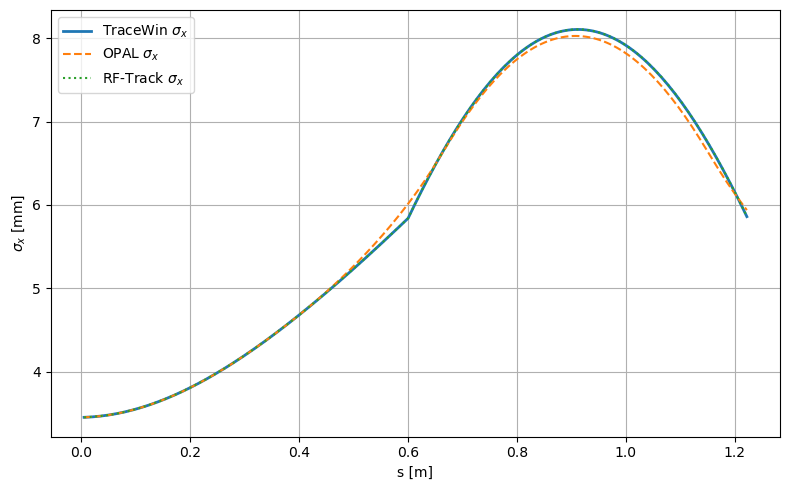

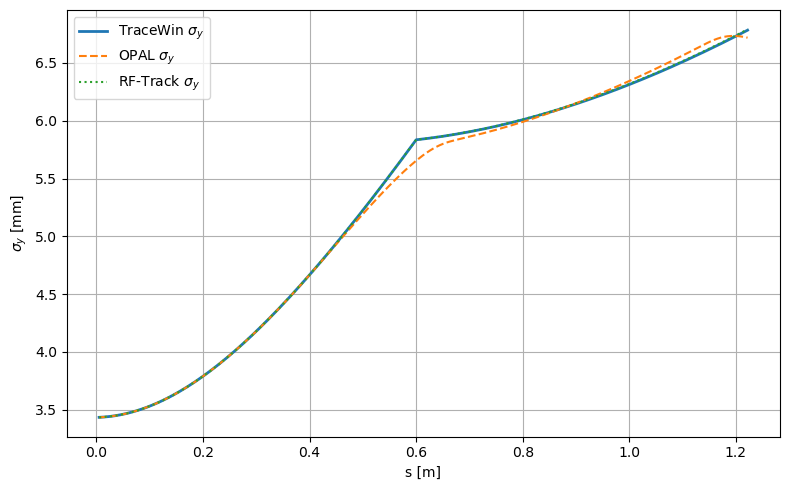

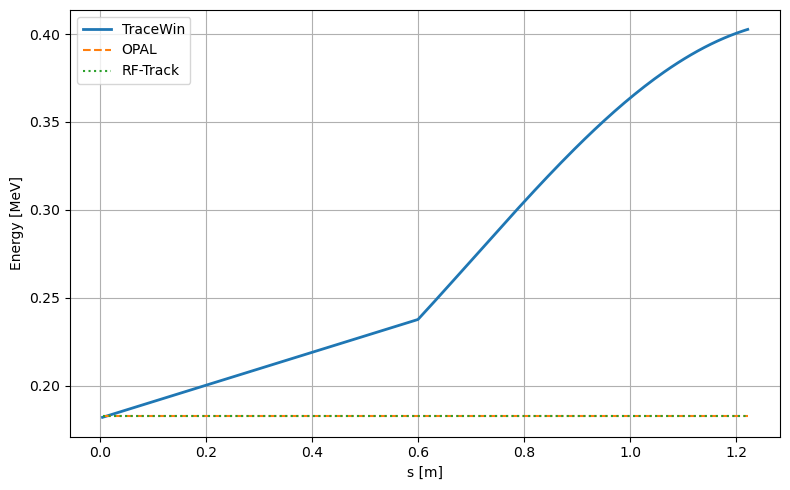

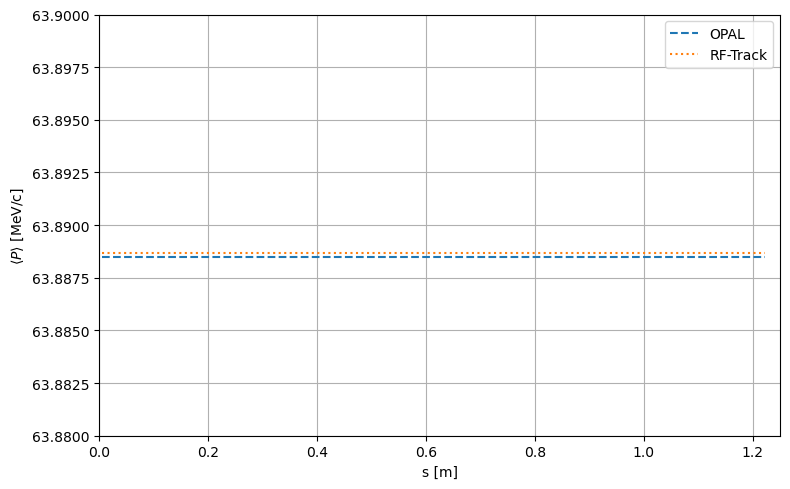

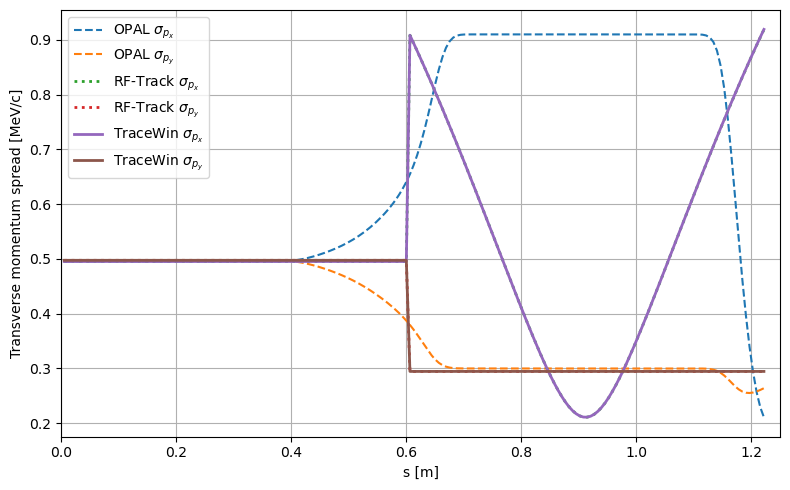

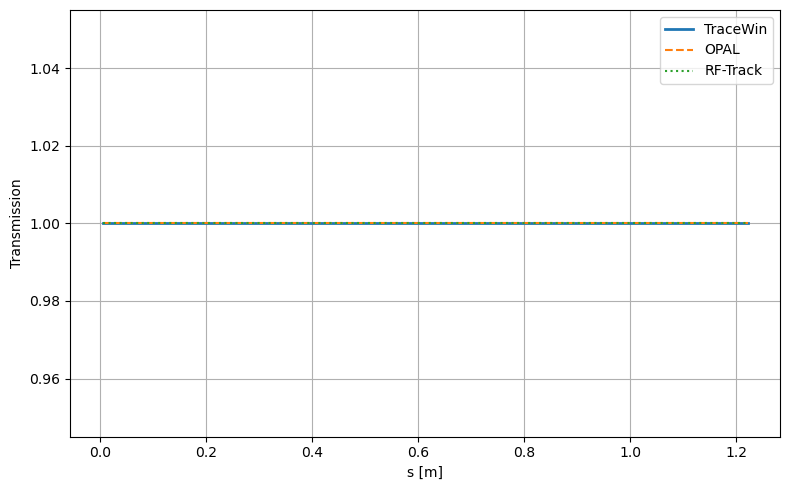

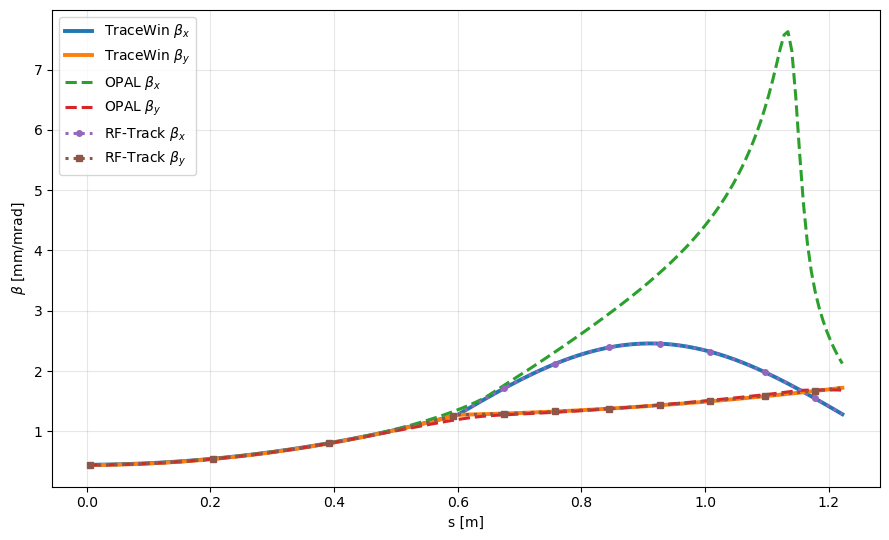

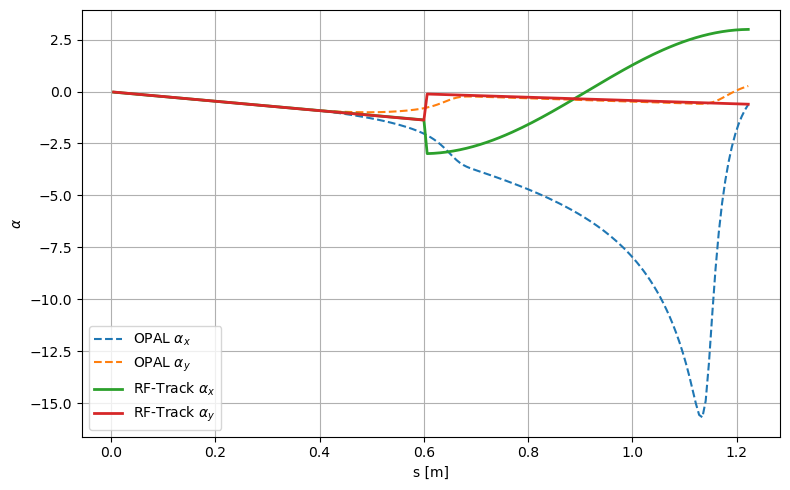

In [ ]:
# RMS x
plt.figure(figsize=(8, 5))
plt.plot(s_common, rms_x_tw_c, label=r"TraceWin $\sigma_x$", linewidth=2)
plt.plot(s_common, rms_x_opal_c, "--", label=r"OPAL $\sigma_x$")
plt.plot(s_common, rms_x_rf_c, ":", label=r"RF-Track $\sigma_x$")
plt.xlabel("s [m]")
plt.ylabel(r"$\sigma_x$ [mm]")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# RMS y
plt.figure(figsize=(8, 5))
plt.plot(s_common, rms_y_tw_c, label=r"TraceWin $\sigma_y$", linewidth=2)
plt.plot(s_common, rms_y_opal_c, "--", label=r"OPAL $\sigma_y$")
plt.plot(s_common, rms_y_rf_c, ":", label=r"RF-Track $\sigma_y$")
plt.xlabel("s [m]")
plt.ylabel(r"$\sigma_y$ [mm]")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Energy
plt.figure(figsize=(8, 5))
plt.plot(s_common, E_tracewin_c, label="TraceWin", linewidth=2)
plt.plot(s_common, E_opal_c, "--", label="OPAL")
plt.plot(s_common, E_rf_c, ":", label="RF-Track")
plt.xlabel("s [m]")
plt.ylabel("Energy [MeV]")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Momentum
plt.figure(figsize=(8, 5))
plt.plot(s_common, P_opal_c, "--", label="OPAL")
plt.plot(s_common, P_rf_c, ":", label="RF-Track")
plt.xlabel("s [m]")
plt.ylabel(r"$\langle P \rangle$ [MeV/c]")
plt.xlim(0, 1.25)
plt.ylim(63.88, 63.90)
plt.ticklabel_format(useOffset=False, style="plain", axis="y")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Transverse momentum spread
plt.figure(figsize=(8, 5))
plt.plot(s_common, sigma_px_opal_mom_c, "--", label=r"OPAL $\sigma_{p_x}$")
plt.plot(s_common, sigma_py_opal_mom_c, "--", label=r"OPAL $\sigma_{p_y}$")
plt.plot(s_common, sigma_px_rf_mom_c, ":", linewidth=2, label=r"RF-Track $\sigma_{p_x}$")
plt.plot(s_common, sigma_py_rf_mom_c, ":", linewidth=2, label=r"RF-Track $\sigma_{p_y}$")
plt.plot(s_common, sigma_px_tracewin_c, "-", linewidth=2, label=r"TraceWin $\sigma_{p_x}$")
plt.plot(s_common, sigma_py_tracewin_c, "-", linewidth=2, label=r"TraceWin $\sigma_{p_y}$")
plt.xlabel("s [m]")
plt.ylabel(r"Transverse momentum spread [MeV/c]")
plt.xlim(0, 1.25)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Transmission
plt.figure(figsize=(8, 5))
plt.plot(s_common, T_tw_c, label="TraceWin", linewidth=2)
plt.plot(s_common, T_opal_c, "--", label="OPAL")
plt.plot(s_common, T_rf_c, ":", label="RF-Track")
plt.xlabel("s [m]")
plt.ylabel("Transmission")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Beta
plt.figure(figsize=(9, 5.5))
plt.plot(s_common, beta_x_tw_c, "-", linewidth=2.8, label=r"TraceWin $\beta_x$")
plt.plot(s_common, beta_y_tw_c, "-", linewidth=2.8, label=r"TraceWin $\beta_y$")
plt.plot(s_common, beta_x_opal_c, "--", linewidth=2.2, label=r"OPAL $\beta_x$")
plt.plot(s_common, beta_y_opal_c, "--", linewidth=2.2, label=r"OPAL $\beta_y$")
plt.plot(s_common, beta_x_rf_c, ":", linewidth=2.2, marker="o", markevery=40, ms=4,
         label=r"RF-Track $\beta_x$")
plt.plot(s_common, beta_y_rf_c, ":", linewidth=2.2, marker="s", markevery=40, ms=4,
         label=r"RF-Track $\beta_y$")
plt.xlabel("s [m]")
plt.ylabel(r"$\beta$ [mm/mrad]")
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

# Alpha
plt.figure(figsize=(8, 5))
plt.plot(s_common, alpha_x_opal_c, "--", label=r"OPAL $\alpha_x$")
plt.plot(s_common, alpha_y_opal_c, "--", label=r"OPAL $\alpha_y$")
plt.plot(s_common, alpha_x_rf_c, label=r"RF-Track $\alpha_x$", linewidth=2)
plt.plot(s_common, alpha_y_rf_c, label=r"RF-Track $\alpha_y$", linewidth=2)
plt.xlabel("s [m]")
plt.ylabel(r"$\alpha$")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
## Relative Errors

In [ ]:

err_x_opal = relative_error_percent(rms_x_opal_c, rms_x_tw_c)
err_y_opal = relative_error_percent(rms_y_opal_c, rms_y_tw_c)
err_T_opal = relative_error_percent(T_opal_c, T_tw_c)

err_x_rf = relative_error_percent(rms_x_rf_c, rms_x_tw_c)
err_y_rf = relative_error_percent(rms_y_rf_c, rms_y_tw_c)
err_T_rf = relative_error_percent(T_rf_c, T_tw_c)


print_stats("OPAL vs TraceWin - sigma_x", err_x_opal)
print_stats("OPAL vs TraceWin - sigma_y", err_y_opal)
print_stats("OPAL vs TraceWin - transmission", err_T_opal)

print_stats("RF-Track vs TraceWin - sigma_x", err_x_rf)
print_stats("RF-Track vs TraceWin - sigma_y", err_y_rf)
print_stats("RF-Track vs TraceWin - transmission", err_T_rf)


OPAL vs TraceWin - sigma_x
  mean relative error       = -0.3989 %
  RMS relative error        =  1.0091 %

OPAL vs TraceWin - sigma_y
  mean relative error       = -0.1527 %
  RMS relative error        =  0.8203 %

OPAL vs TraceWin - transmission
  mean relative error       =  0.0000 %
  RMS relative error        =  0.0000 %

RF-Track vs TraceWin - sigma_x
  mean relative error       =  0.0117 %
  RMS relative error        =  0.0171 %

RF-Track vs TraceWin - sigma_y
  mean relative error       =  0.0423 %
  RMS relative error        =  0.0547 %

RF-Track vs TraceWin - transmission
  mean relative error       =  0.0000 %
  RMS relative error        =  0.0000 %
